In [64]:
import abtem
import ase
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk

(examples:cbed_quickstart)=
# CBED quickstart

This notebook demonstrates a basic CBED simulation of silicon in the $(111)$ zone axis.

## Configuration

We start by (optionally) setting our configuration. See [documentation](reference:configuration) for details.

In [65]:
abtem.config.set(
    {
        "device": "gpu",
        "fft": "numpy",
        "diagnostics.task_progress": True,
        "diagnostics.progress_bar": "tqdm",
    }
)

## Atomic model
We create the atomic model. See our [walkthough](walkthrough:atomic_models) or our [tutorial](tutorials:advanced_atomic_models) on atomic models. 

We create an atomic model of silicon using the `bulk` function from ASE.

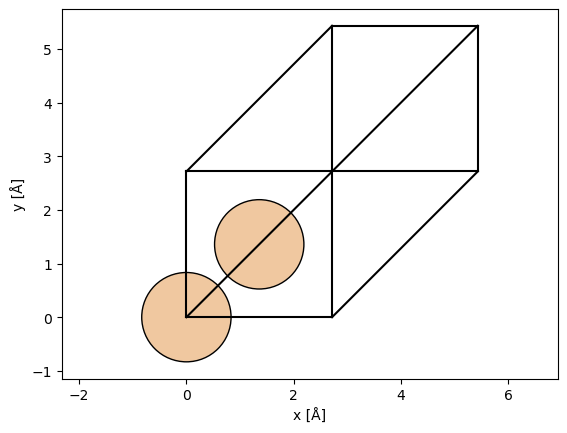

In [66]:
silicon = bulk("Si", crystalstructure="diamond")

abtem.show_atoms(silicon, plane="xy");

We can choose the $(111)$ zone axis to be a propagation direction using the `surface` function. 

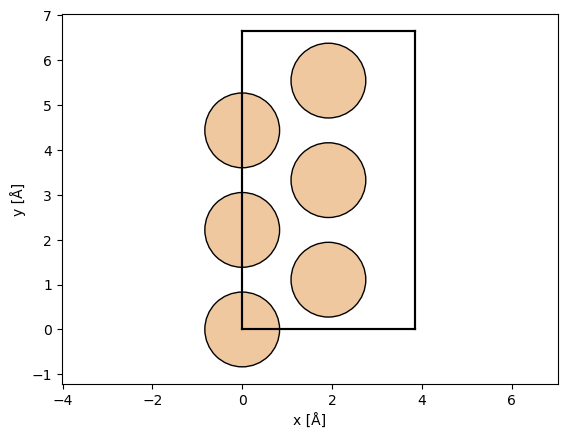

In [67]:
silicon_111 = ase.build.surface(
    silicon, (1, 1, 1), layers=3, periodic=True
)  # create surface structure in the (111) direction

silicon_111_orthogonal = abtem.orthogonalize_cell(silicon_111)  # make cell orthogonal

abtem.show_atoms(silicon_111_orthogonal);

Finally we repeat the structure in $x$ and $y$, this will improve the reciprocal space resolution. We also repeat the structure in $z$, thus simulating a thicker sample.

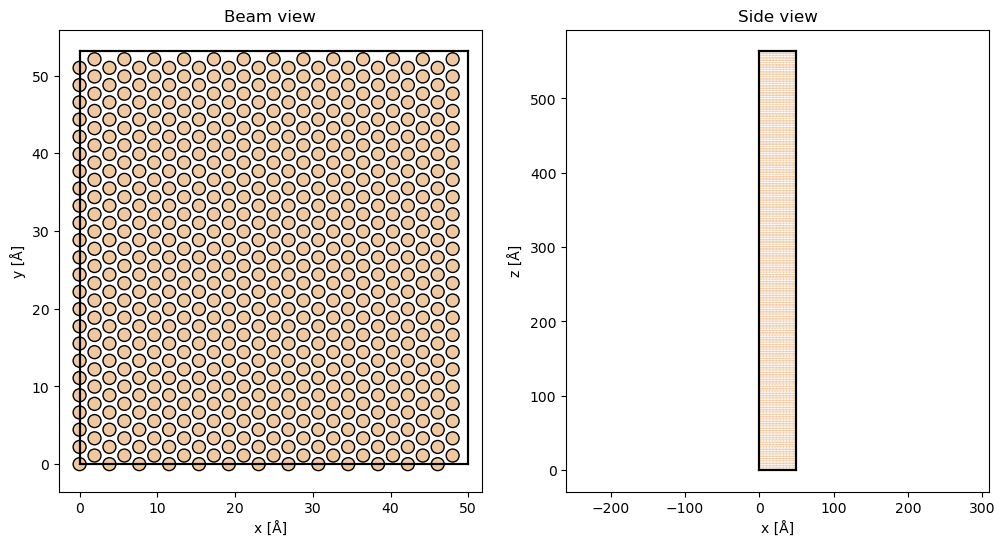

In [68]:
atoms = silicon_111_orthogonal * (13, 8, 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
abtem.show_atoms(atoms, ax=ax1, title="Beam view")
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Side view", linewidth=0.0);

## Potential

We create an ensemble of potentials using the frozen phonon. See our [walkthrough on frozen phonons](walkthrough:frozen_phonons). 

In [69]:
frozen_phonons = abtem.FrozenPhonons(atoms=atoms, num_configs=20,sigmas={"Si": 0.008}, seed=30085)

We create a potential from the frozen phonons model, see [walkthrough on potentials](walkthrough:potentials).

In [70]:
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,
    projection="infinite",
    slice_thickness=2,
    exit_planes=60,
)

## Wave function

We create a probe wave function at an energy of 100 keV with a convergence semiangle of $9.4 \ \mathrm{mrad}$. See our [walkthrough on wave functions](walkthrough:wave_functions). 

Partial temporal coherence is neglected here, see our [tutorial on partial coherence](tutorials:partial_coherence) if you want to include this in your simulation.

In [71]:
wave = abtem.Probe(energy=100e3, semiangle_cutoff=9.4)
wave.grid.match(potential)

[########################################] | 100% Completed | 100.99 ms


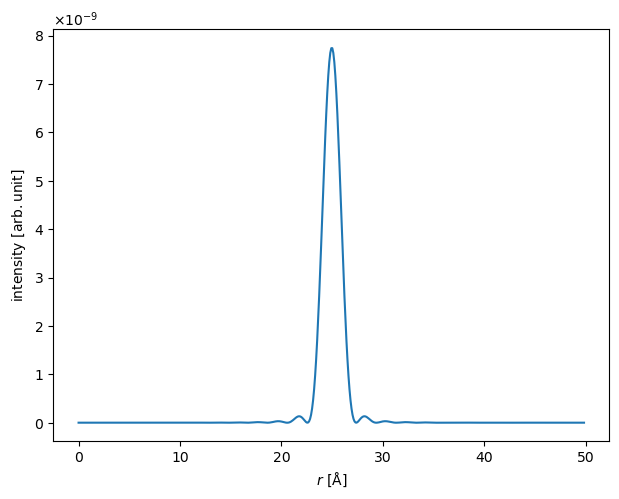

In [72]:
wave.profiles().show();

## Multislice

We run the multislice algorithm and calculate the diffraction patterns, see our [walkthrough on multislice](walkthrough:multislice).

In [73]:
measurement = wave.multislice(potential).diffraction_patterns(max_angle=70)

We take the mean across the frozen phonons axis, and compute the result.

In [ ]:
measurement = measurement.mean(0)

measurement.compute()

[########################################] | 100% Completed | 10.21 s


## Visualize results

We show the thickness series as an exploded plot.

In [75]:
atoms.get_cell_lengths_and_angles()

/tmp/ipykernel_4013594/3835351656.py:1: DeprecationWarning: Please use atoms.cell.cellpar() instead
  atoms.get_cell_lengths_and_angles()


array([ 49.91466768,  53.20291721, 564.30215311,  90.        ,
        90.        ,  90.        ])

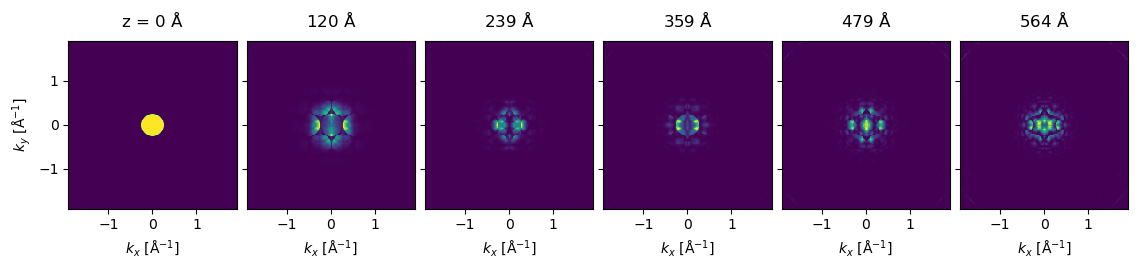

In [76]:
visualization = measurement.show(
    explode=True,
    figsize=(12, 5),
)

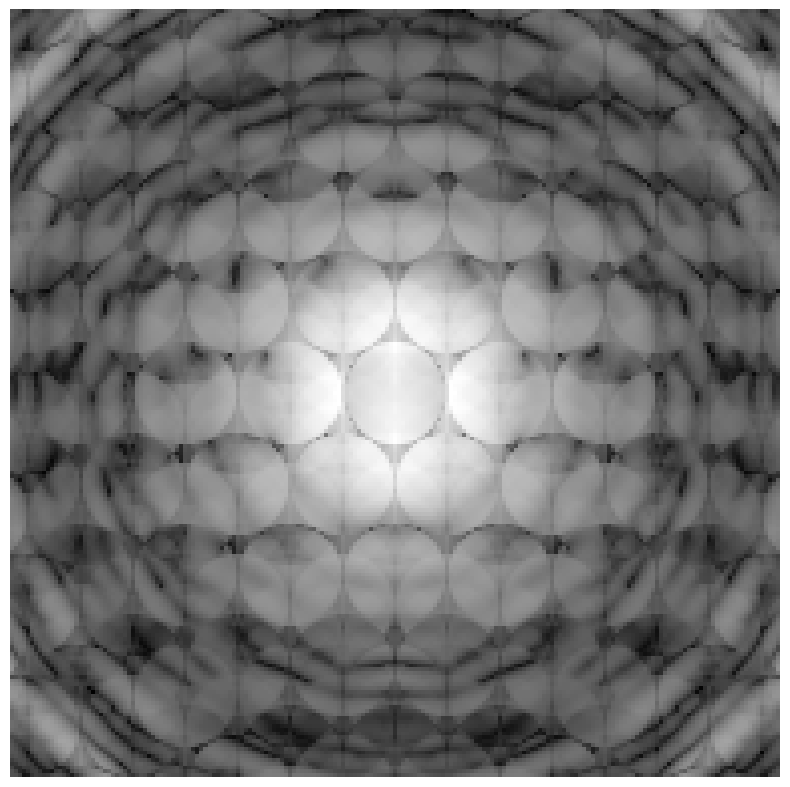

In [77]:
fig, ax = plt.subplots(figsize=(8, 8))
measurement[1].show(ax=ax, cmap="gray", logscale=True)
ax.axis('off')  # 隐藏坐标轴和刻度
plt.tight_layout()  # 自动调整布局，防止图形超出边界
plt.savefig("../thumbnails/cbed_quickstart.png", bbox_inches='tight', pad_inches=0, dpi=200)
#plt.close()  # 关闭图形释放内存

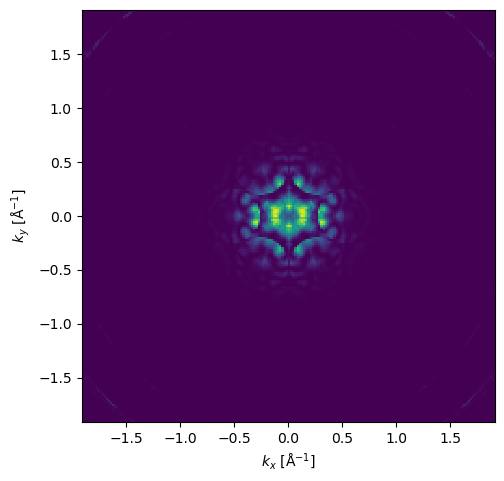

In [78]:
# this cell produces a thumbnail for the online documentation

visualization = measurement[-1].show()
#visualization.axis_off()
plt.savefig("../thumbnails/cbed_quickstart.png", bbox_inches="tight", pad_inches=0)

In [79]:
import glob
from ase.io import read, write
from matplotlib import pyplot as plt
import abtem
import os

# run lammps
nve_dir = "/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve"

snapshots= glob.glob(os.path.join(nve_dir,'*.lammps'))

# LAMMPS类型映射: 1=O, 2=Pb, 3=Ti
type_map = {1: 8, 2: 82, 3: 22}  # O=8, Pb=82, Ti=22 (原子序数)

measurements = []
for snapshot in snapshots:
    print(snapshot)
    if snapshot.endswith('snapshot_avg.lammps'):
        print(f"skip {snapshot}")   
        continue
    atoms = read(snapshot, format='lammps-data')
    
    # 重新映射原子类型
    new_numbers = [type_map[num] for num in atoms.numbers]
    atoms.set_atomic_numbers(new_numbers)
    
    desired_rotation = 90
    rotate_atoms = atoms.copy()
    rotate_atoms.rotate(desired_rotation, "y", rotate_cell=True)
    rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
    rotate_atoms.center()
    atoms = rotate_atoms.copy()

    # 计算势场
    lammps_phonons = abtem.FrozenPhonons(atoms, 1, sigmas={'O': 0.0, 'Pb': 0.0, 'Ti': 0.0})
    potential = abtem.Potential(lammps_phonons, sampling=0.05)

    # 创建探针
    wave = abtem.Probe(energy=100e3, semiangle_cutoff=9.4)
    wave.grid.match(potential)

    measurement = wave.multislice(potential).diffraction_patterns(max_angle=150)
    measurements.append(measurement)


/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_79.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_83.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_86.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_89.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_9.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_93.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_96.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_29.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_3.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_33.lammps
/media/chenguisen/WD_BLACK/AISI/DeepMD-EM/PbTiO3/293K/supercell_8x9x32/nve/snap_36.lammps
/media/cheng

In [80]:

measurement = measurements[0]
for i in range(1, len(measurements)):
    measurement = measurement + measurements[i]

measurement.compute()

[########################################] | 100% Completed | 7.71 sms


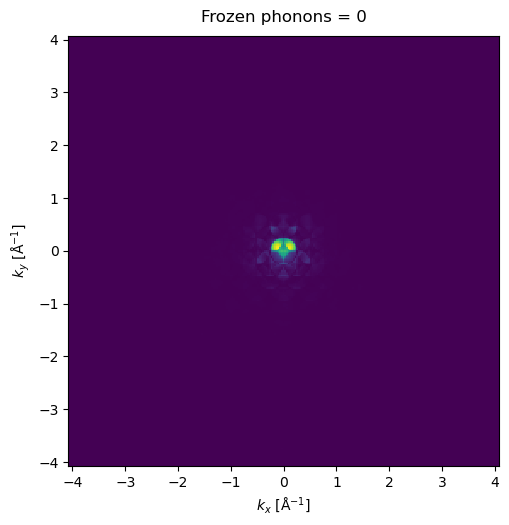

In [81]:
visualization = measurement.show(
    explode=True,
    figsize=(12, 5),
)

Log范围: vmin=12.1993, vmax=122877.6016
数据范围: min=4.7005, max=122877.6016
放大倍数: 1e6


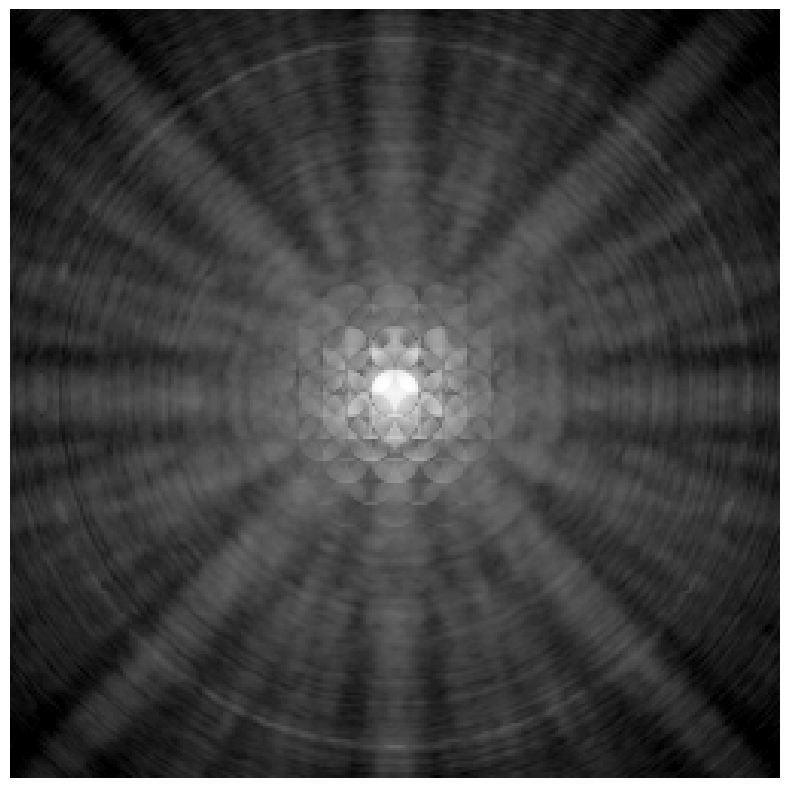

In [82]:
fig, ax = plt.subplots(figsize=(8, 8))

# 将数据乘以1e6进行放大，提高对比度
measurement_scaled = measurement * 1e6

# 计算数据的百分比范围以优化log显示
data = measurement_scaled.array
# 排除0值计算统计
valid_data = data[data > 0]
if len(valid_data) > 0:
    # 使用percentile来调整范围
    vmin_val = np.percentile(valid_data, 1)   # 1%位置
    vmax_val = np.percentile(valid_data, 100)  # 99%位置
    
    measurement_scaled.show(ax=ax, cmap="gray", logscale=True, vmin=vmin_val, vmax=vmax_val)
else:
    measurement_scaled.show(ax=ax, cmap="gray", logscale=True)

ax.axis('off')  # 隐藏坐标轴和刻度
plt.tight_layout()  # 自动调整布局，防止图形超出边界

print(f"Log范围: vmin={vmin_val:.4f}, vmax={vmax_val:.4f}")
print(f"数据范围: min={valid_data.min():.4f}, max={valid_data.max():.4f}")
print(f"放大倍数: 1e6")

In [94]:
# run frozen phonons model
average_snapshot = os.path.join(nve_dir,'snapshot_avg.lammps')
average_atoms = read(average_snapshot, format='lammps-data')

# LAMMPS类型映射: 1=O, 2=Pb, 3=Ti -> 重新映射为正确的原子序数
type_map = {1: 8, 2: 82, 3: 22}  # O=8, Pb=82, Ti=22
new_numbers = [type_map[num] for num in average_atoms.numbers]
average_atoms.set_atomic_numbers(new_numbers)

desired_rotation = 90
rotate_atoms = average_atoms.copy()
rotate_atoms.rotate(desired_rotation, "y", rotate_cell=True)
rotate_atoms.rotate(desired_rotation, "z", rotate_cell=True)
rotate_atoms.center()
average_atoms = rotate_atoms.copy()
# 1,0.089883,0.083568,0.082489
# 2,0.089093,0.098905,0.097031
# 3,0.076666,0.061879,0.060748
# 计算势场 - 使用元素符号作为键
fp_phonons = abtem.FrozenPhonons(average_atoms, 30, sigmas={'O': [0.089883,0.083568,0.082489], 'Pb': [0.089093,0.098905,0.097031], 'Ti': [0.076666,0.061879,0.060748]})
# fp_phonons = abtem.FrozenPhonons(average_atoms, 30, sigmas={'O': 0, 'Pb': 0, 'Ti': 0})
fp_potential = abtem.Potential(fp_phonons, sampling=0.05)


# 创建探针
fp_wave = abtem.Probe(energy=100e3, semiangle_cutoff=9.4)
fp_wave.grid.match(fp_potential)

fp_measurement = fp_wave.multislice(fp_potential).diffraction_patterns(max_angle=150)
fp_measurement = fp_measurement.mean(0)
fp_measurement.compute()

[########################################] | 100% Completed | 7.31 sms


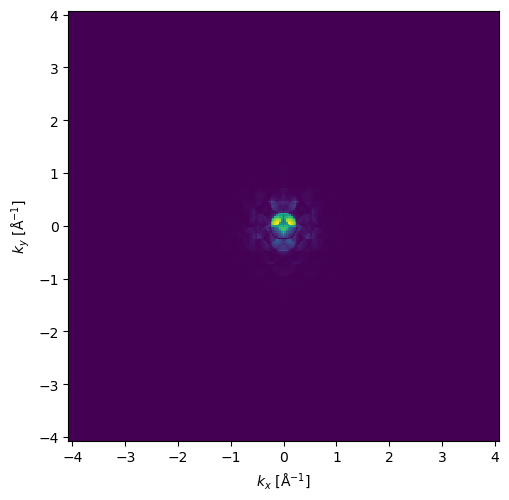

In [97]:
fp_measurement.show(
    explode=True,
    figsize=(12, 5),
)

Log范围: vmin=0.2998, vmax=3940.0481
数据范围: min=0.1293, max=3940.0481
放大倍数: 1e6


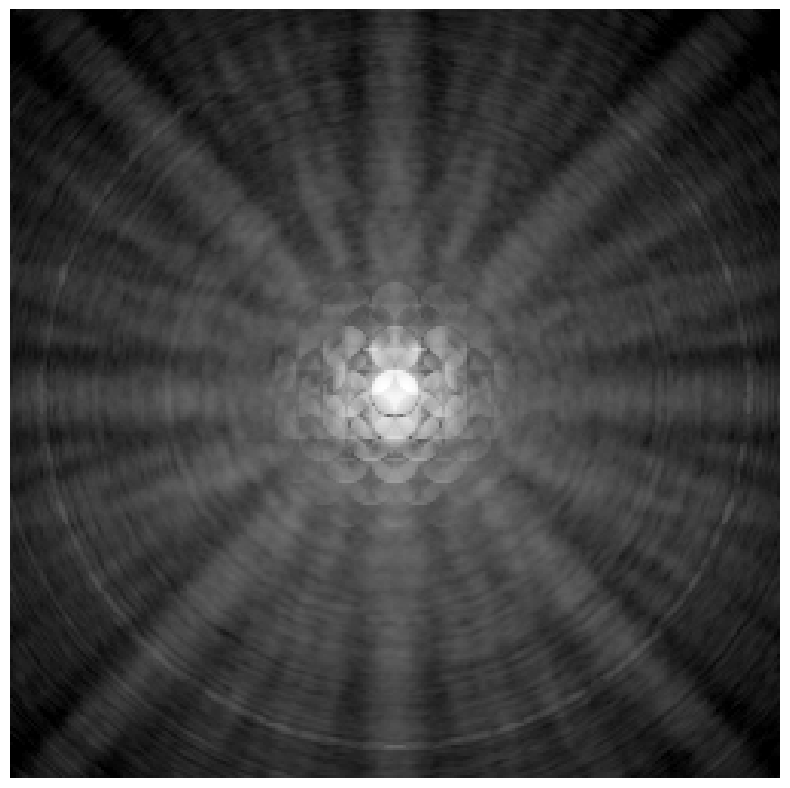

In [96]:
fig, ax = plt.subplots(figsize=(8, 8))

# 将数据乘以1e6进行放大，提高对比度
measurement_scaled = fp_measurement * 1e6

# 计算数据的百分比范围以优化log显示
data = measurement_scaled.array
# 排除0值计算统计
valid_data = data[data > 0]
if len(valid_data) > 0:
    # 使用percentile来调整范围
    vmin_val = np.percentile(valid_data, 1)   # 1%位置
    vmax_val = np.percentile(valid_data, 100)  # 99%位置
    
    measurement_scaled.show(ax=ax, cmap="gray", logscale=True, vmin=vmin_val, vmax=vmax_val)
else:
    measurement_scaled.show(ax=ax, cmap="gray", logscale=True)

ax.axis('off')  # 隐藏坐标轴和刻度
plt.tight_layout()  # 自动调整布局，防止图形超出边界

print(f"Log范围: vmin={vmin_val:.4f}, vmax={vmax_val:.4f}")
print(f"数据范围: min={valid_data.min():.4f}, max={valid_data.max():.4f}")
print(f"放大倍数: 1e6")